In [1]:
%load_ext autoreload
%autoreload 2

import inspect
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math, HTML
from pyGDM2 import materials, structures

from optomechanics_levitation import particle_properties, translate_particle, rotate_particle

# Particle definition

The `particle_properties` function constructs a discretized particle from a PyGDM geometry generator and material constructor. The `particle_type` and `material_name` arguments select these objects by name. The `step_nm` argument sets the discretization spacing in nanometers, `mesh` selects the mesh type, and `center` determines whether the discrete geometry is centered. Additional keyword arguments are passed directly to the selected geometry generator.

For the `spheroid` generator, `R1`, `R2`, and `R3` are the Cartesian semiaxes expressed in units of `step_nm`. Thus, each nominal physical semiaxis is the corresponding dimensionless radius multiplied by the discretization step. The call below defines a silica spheroid on a hexagonal mesh with `step_nm=10`.

The available [particle geometries](https://homepages.laas.fr/pwiecha/pygdm_doc/apidoc_sim_description.html) and [materials](https://homepages.laas.fr/pwiecha/pygdm_doc/apidoc_sim_description.html#materials) are documented by PyGDM.

In [2]:
ellipsoidal_particle_properties = particle_properties(particle_type="spheroid", material_name="sio2", step_nm=10, mesh="hex", center=True, R1=5, R2=5, R3=10)

The function returns a dictionary containing exactly the following entries:

- `geometry_nm`: a floating-point array of shape $(N \times 3)$, where $N$ is the number of discretization points. Each row contains the Cartesian coordinates $(x,y,z)$ of one point in nanometers.
- `material`: the selected PyGDM material object. Its wavelength-dependent relative permittivity is available through `material.epsilon(wavelength_nm)`, where the wavelength is specified in nanometers.
- `step_nm`: the discretization step in nanometers.
- `mesh`: the mesh type supplied to the geometry generator.

For a particle with fixed physical dimensions, refining the discretization gives the approximate scaling

$$
N \propto \frac{1}{s^3},
$$

where $s$ is `step_nm`, provided that the generator's dimensionless radii are adjusted to keep the physical semiaxes fixed. Changing only `step_nm` while keeping `R1`, `R2`, and `R3` fixed changes the physical size of the spheroid and preserves $N$.

With `center=True`, the implementation subtracts the mean position of all discretization points. This places the centroid of the sampled geometry at $(0,0,0)$ nm, up to floating-point precision.

In [3]:
centroid_nm = ellipsoidal_particle_properties["geometry_nm"].mean(axis=0)
step_nm = ellipsoidal_particle_properties["step_nm"]

def sci_notation(value, decimals):
    """ Function to write values in scientific notation """
    mantissa, exponent = f"{value:.{decimals}e}".split("e")
    return rf"{mantissa} \times 10^{{{int(exponent)}}}" 

display(Markdown(r"### Nanoparticle's center position"))
display(Math(
    rf"\bar{{\mathbf{{r}}}}_0 = "
    rf"({sci_notation(centroid_nm[0], 2)},\,{sci_notation(centroid_nm[1], 2)},\,{sci_notation(centroid_nm[2], 2)})"
    rf"\ \mathrm{{nm}}"
))
display(Markdown(f"Centroid located at the origin: **{np.allclose(centroid_nm, (0, 0, 0), atol=step_nm * 1e-10)}**"))

### Nanoparticle's center position

<IPython.core.display.Math object>

Centroid located at the origin: **True**

# Translation and rotation

The translation adds the displacement vector $[d_x,d_y,d_z]$ to every point, with all components expressed in nanometers. Here, the displacement is $[0,50,0]$ nm, so the particle moves by 50 nm along the laboratory $y$ axis.

The rotation is specified by `[angle_x, angle_y, angle_z]` in degrees. The implementation applies successive active rotations about the fixed laboratory $x$, $y$, and $z$ axes, in that order. The rotation origin is the point that remains fixed; its default value is $(0,0,0)$ nm, which is used below. The angles in this example are $[0,47,15]$ degrees.

Both transformations return new coordinate arrays. They do not regenerate the geometry and therefore preserve the number and order of the discretization points.

In [4]:
original_geometry = ellipsoidal_particle_properties["geometry_nm"]
translated_ellipsoid = translate_particle(initial_geometry=original_geometry, displacement_nm=[0.0, 50.0, 0.0])
rotated_ellipsoid = rotate_particle(initial_geometry=original_geometry, angles_deg=[0.0, 47.0, 15.0])

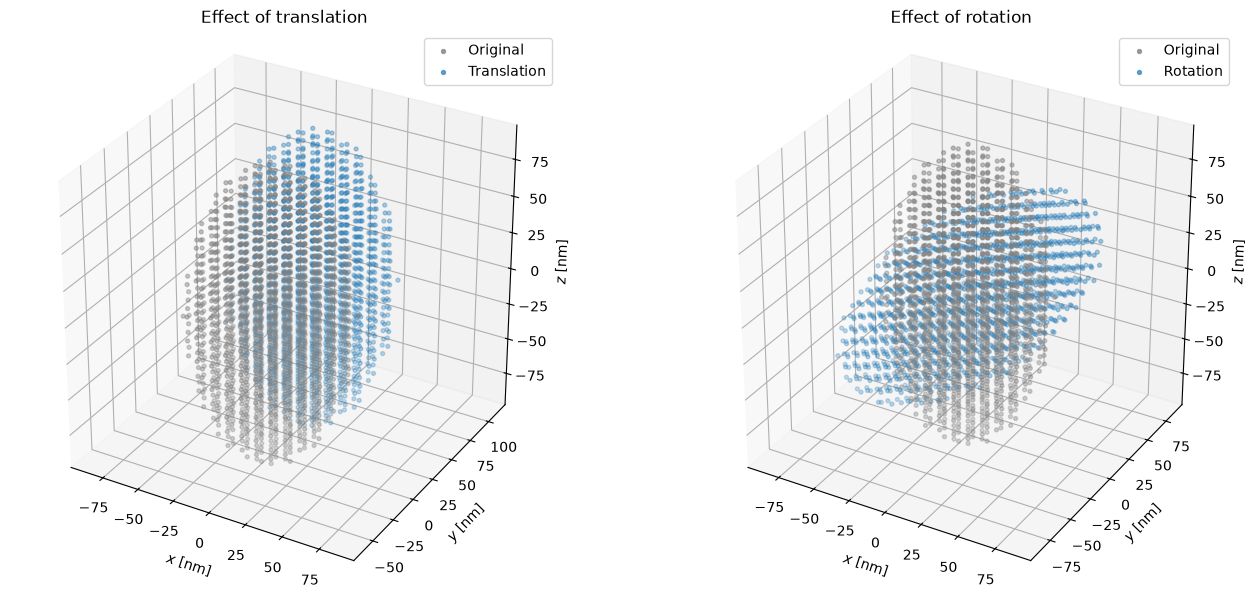

In [5]:
fig = plt.figure(figsize=(14, 6))
ax_translation = fig.add_subplot(1, 2, 1, projection="3d")
ax_rotation = fig.add_subplot(1, 2, 2, projection="3d")

plots = [(ax_translation, translated_ellipsoid, "Translation"), (ax_rotation, rotated_ellipsoid, "Rotation")]
for ax, transformed_geometry, title in plots:
    ax.scatter(original_geometry[:, 0], original_geometry[:, 1], original_geometry[:, 2], s=8, alpha=0.75, color="gray", label="Original")
    ax.scatter(transformed_geometry[:, 0], transformed_geometry[:, 1], transformed_geometry[:, 2], s=8, alpha=0.65, label=title)

    combined_geometry = np.vstack((original_geometry, transformed_geometry))
    minimum = combined_geometry.min(axis=0)
    maximum = combined_geometry.max(axis=0)
    midpoint = (minimum + maximum) / 2
    half_range = (maximum - minimum).max() / 2

    ax.set_xlim(midpoint[0] - half_range, midpoint[0] + half_range)
    ax.set_ylim(midpoint[1] - half_range, midpoint[1] + half_range)
    ax.set_zlim(midpoint[2] - half_range, midpoint[2] + half_range)
    ax.set_box_aspect((1, 1, 1))

    ax.set_xlabel(r"$x$ [nm]")
    ax.set_ylabel(r"$y$ [nm]")
    ax.set_zlabel(r"$z$ [nm]")
    ax.set_title(f"Effect of {title.lower()}")
    ax.legend()

plt.tight_layout()
plt.show()